# Heart Disease UCI - Exploratory Data Analysis

This notebook performs EDA on the Heart Disease UCI dataset (Cleveland subset).

**Dataset**: 303 patients, 13 features, binary target (disease present / absent).

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

from configs.config import FEATURE_NAMES, TARGET_NAME, COLUMN_NAMES

os.makedirs(os.path.join(PROJECT_ROOT, 'screenshots'), exist_ok=True)

## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/raw/heart.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


## 2. Missing Values Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print('Missing values per column:')
print(missing_df[missing_df['Count'] > 0])
print(f'\nTotal rows with any missing: {df.isnull().any(axis=1).sum()}')

Missing values per column:
      Count  Percentage
ca        4        1.32
thal      2        0.66

Total rows with any missing: 6


## 3. Target Class Distribution

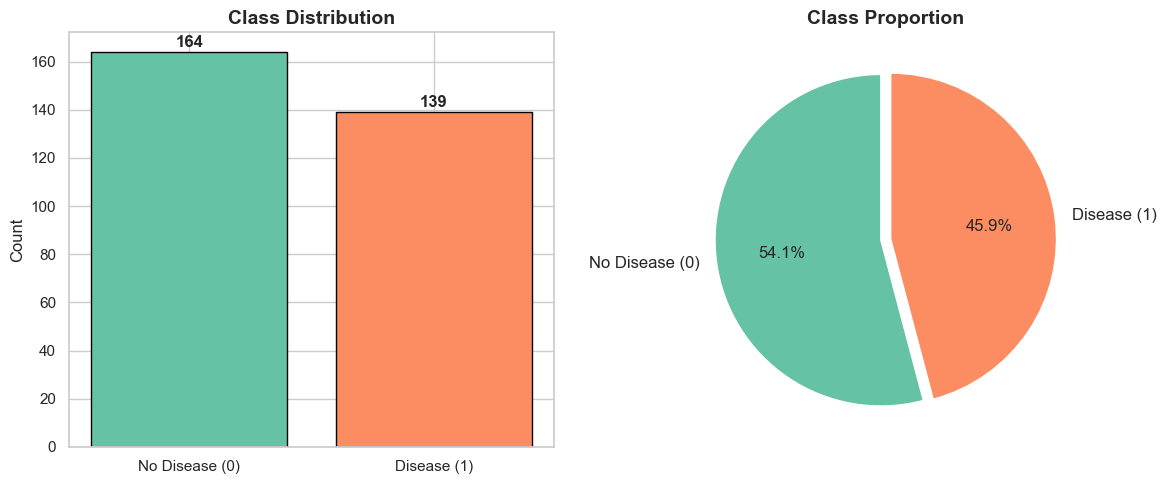

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df[TARGET_NAME].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']

axes[0].bar(labels, target_counts.values, color=['#66c2a5', '#fc8d62'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90,
            explode=(0.03, 0.03), textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Distributions (Histograms)

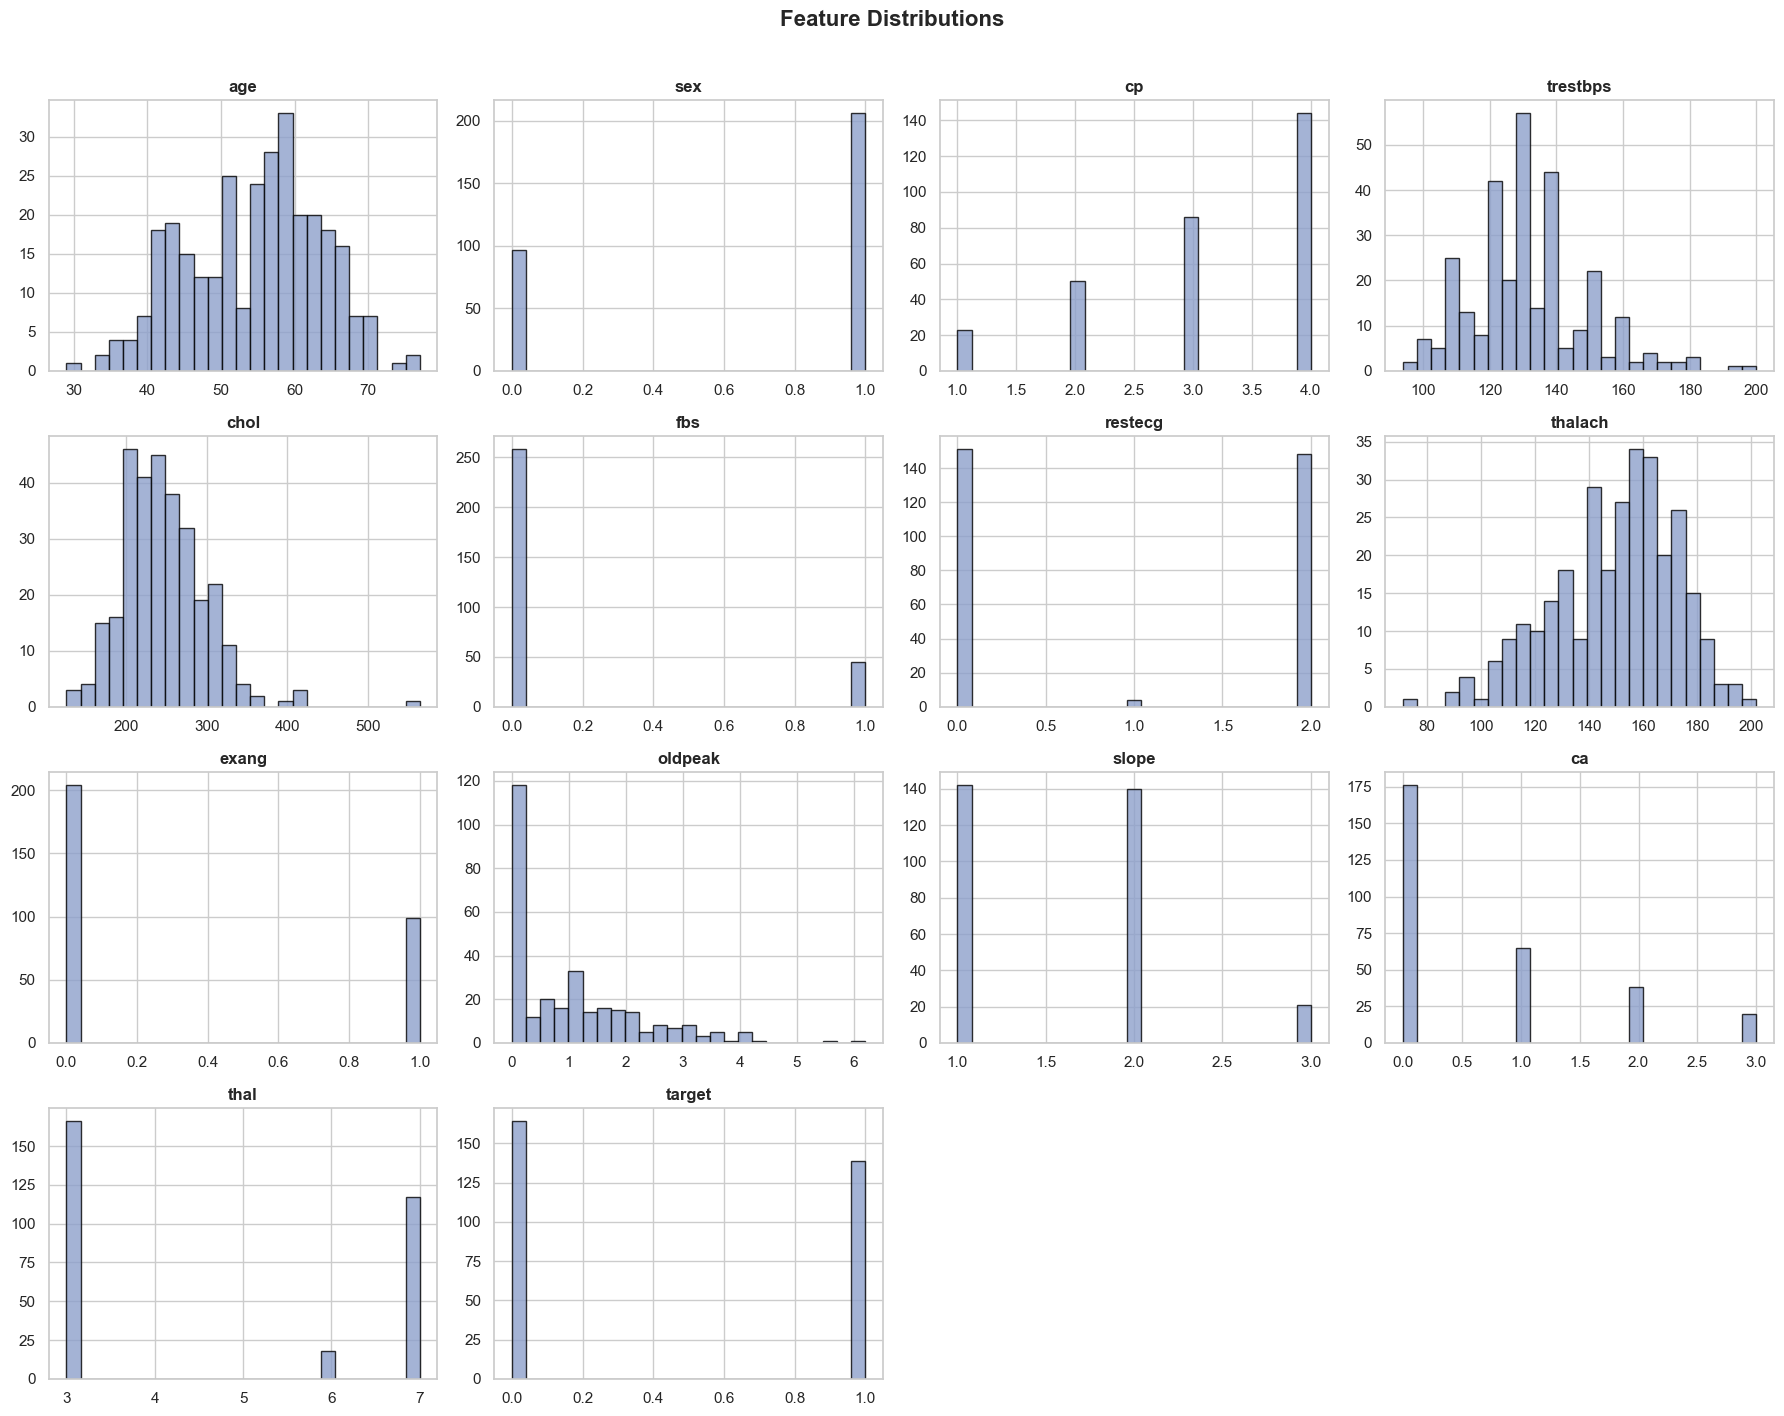

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(COLUMN_NAMES):
    ax = axes[i]
    df[col].hist(bins=25, ax=ax, color='#8da0cb', edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(COLUMN_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../screenshots/feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

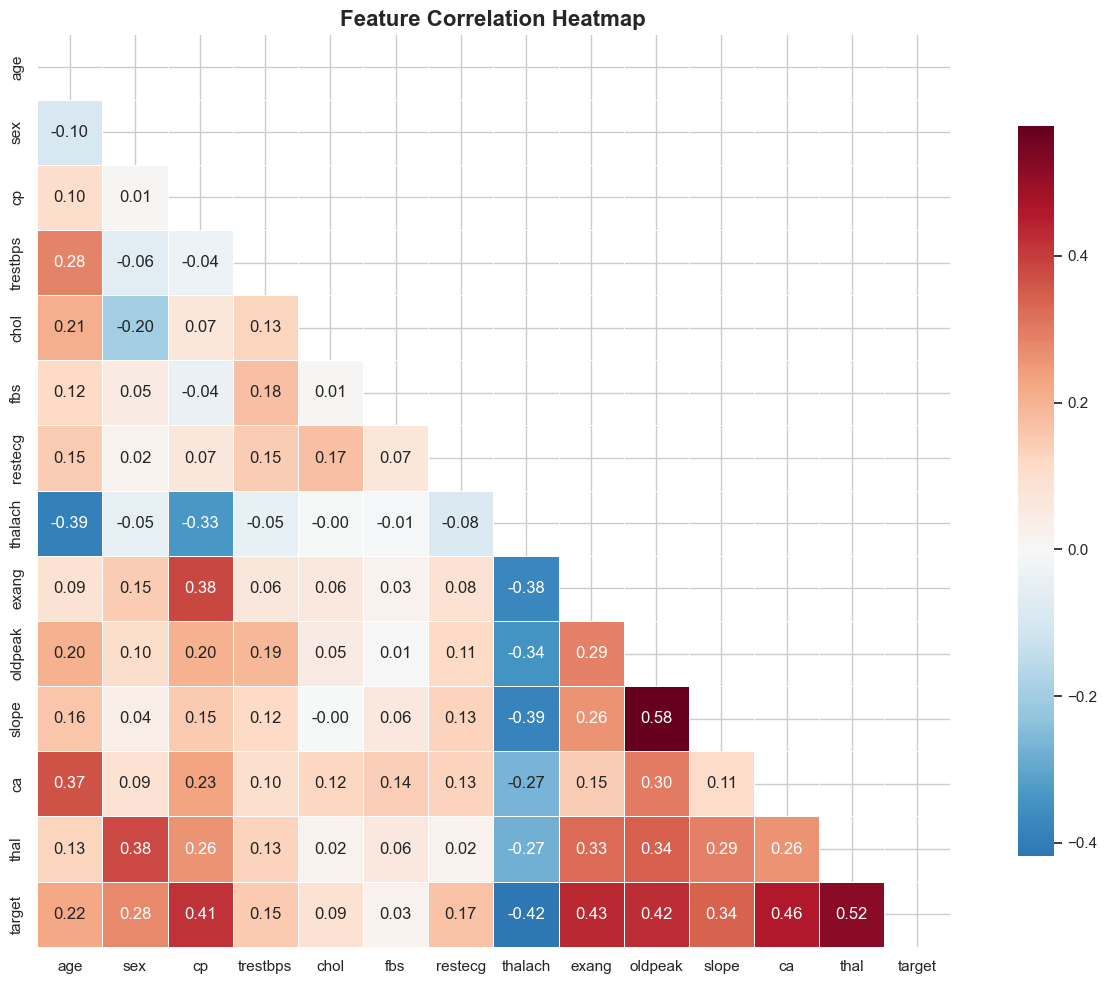

In [8]:
# Fill missing for correlation computation
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

plt.figure(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Box Plots by Target

/var/folders/cd/s_smlzv15l76bhz4nlb30tz00000gn/T/ipykernel_19293/2501147003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=TARGET_NAME, y=col, ax=axes[i],
/var/folders/cd/s_smlzv15l76bhz4nlb30tz00000gn/T/ipykernel_19293/2501147003.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Disease', 'Disease'])
/var/folders/cd/s_smlzv15l76bhz4nlb30tz00000gn/T/ipykernel_19293/2501147003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=TARGET_NAME, y=col, ax=axes[i],
/var/folders/cd/s_smlzv15l76bhz4nlb30tz00000gn/T/ipykernel_19293/2501147003.py:9:

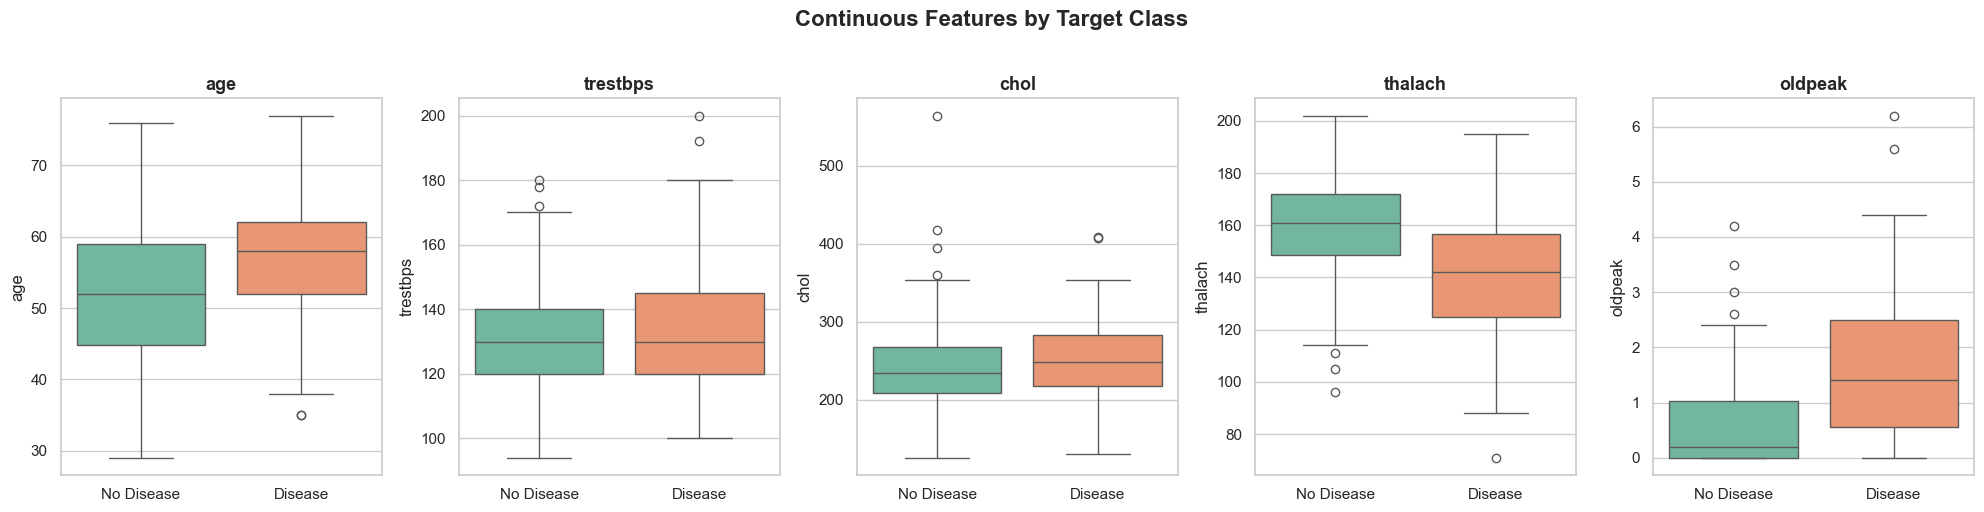

In [9]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(continuous_features), figsize=(20, 5))

for i, col in enumerate(continuous_features):
    sns.boxplot(data=df_clean, x=TARGET_NAME, y=col, ax=axes[i],
                palette=['#66c2a5', '#fc8d62'])
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features by Target Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Categorical Features by Target

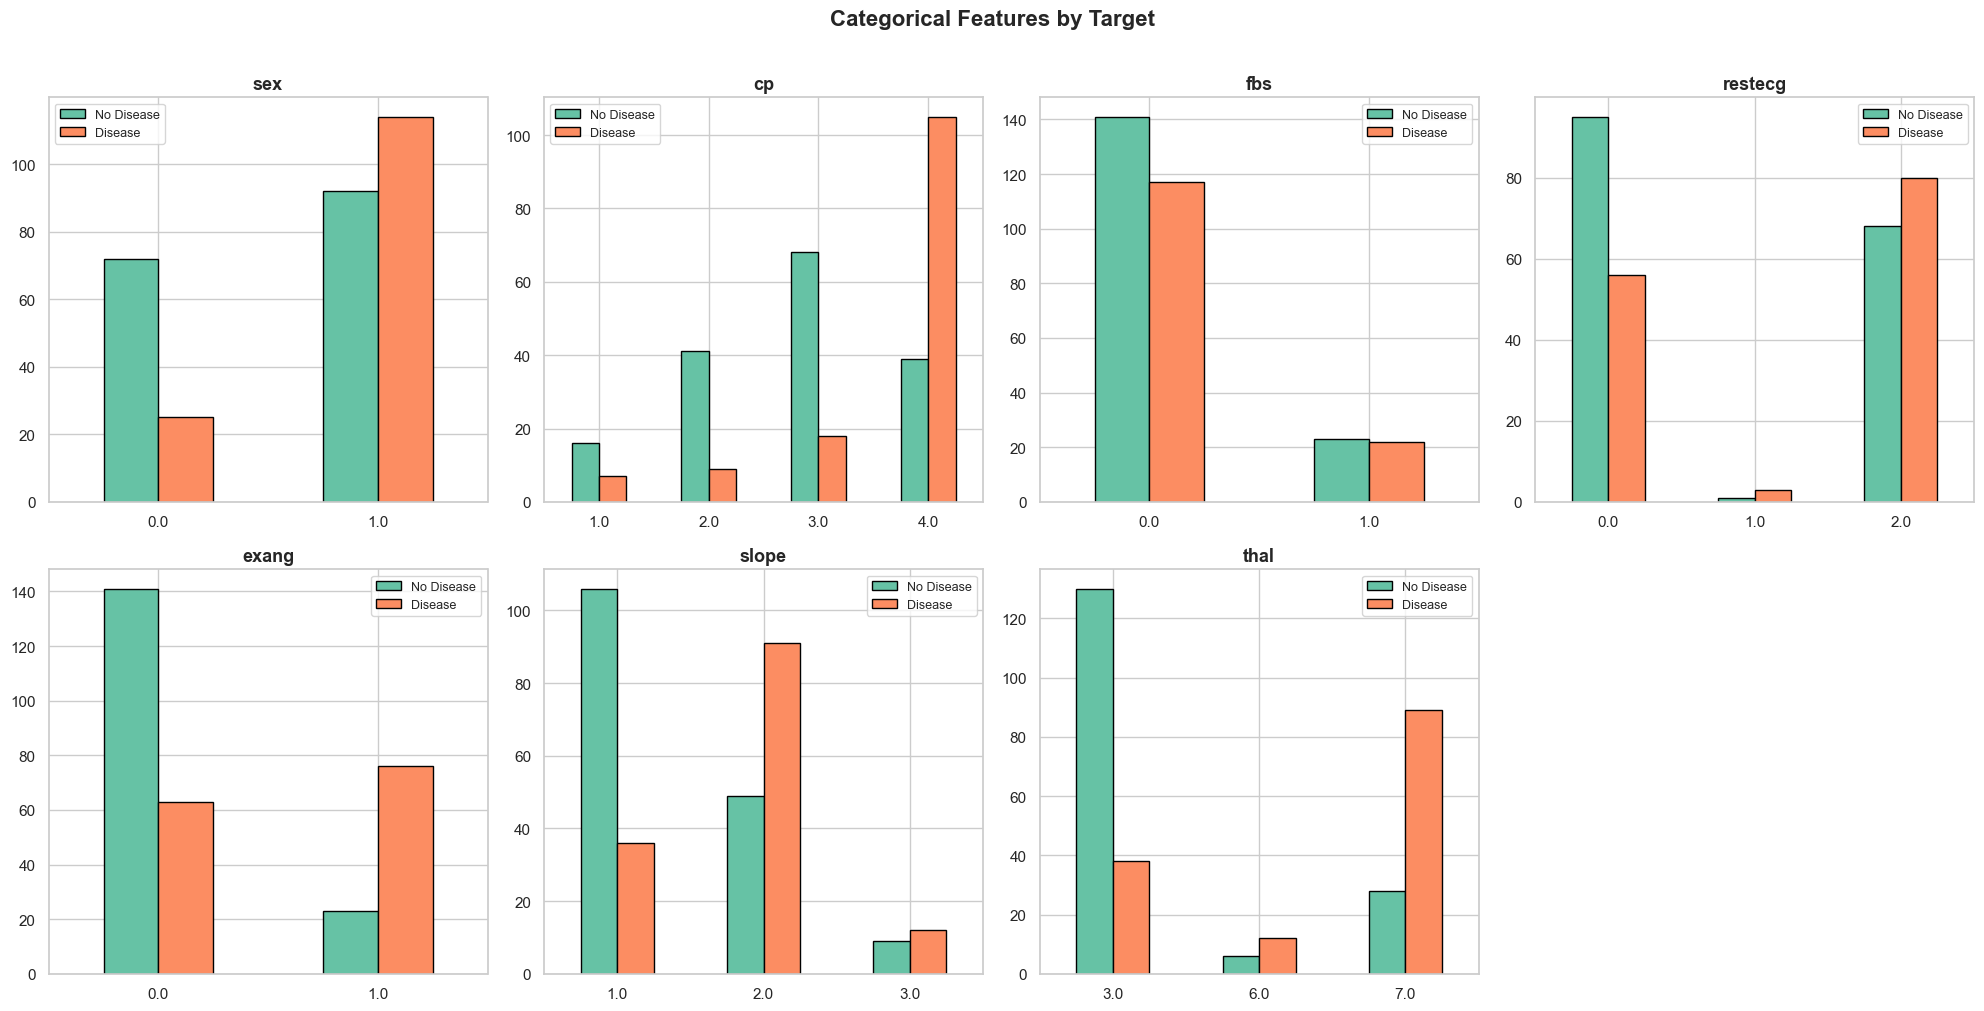

In [10]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df_clean[col], df_clean[TARGET_NAME])
    ct.plot(kind='bar', ax=axes[i], color=['#66c2a5', '#fc8d62'], edgecolor='black')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['No Disease', 'Disease'], fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)

plt.suptitle('Categorical Features by Target', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../screenshots/categorical_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Observations

- **Dataset size**: 303 samples, 13 features, 1 binary target.
- **Missing values**: `ca` and `thal` have a few missing entries (marked as `?`), handled via median imputation.
- **Class balance**: Roughly balanced (~54% no disease, ~46% disease).
- **Correlated features**: `cp`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, and `thal` show strong correlations with the target.
- **Age**: Disease patients tend to be slightly older.
- **Max heart rate (`thalach`)**: Healthy patients achieve higher max heart rates.
- **ST depression (`oldpeak`)**: Higher in disease patients.
- **Chest pain type (`cp`)**: Asymptomatic (type 4) is highly associated with disease.